# CICIoT2023 Baseline Evaluation
**Team Member 1 — Section A: Baseline ML Models**

This notebook:
1. Loads all trained models from `models/`
2. Evaluates them on the held-out test set
3. Produces a comparison table and confusion matrix
4. *(Stubs for Member 2's spectral features and Member 3's federated eval)*

In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
print('Setup complete.')

Setup complete.


## 1. Load Preprocessed Data

In [2]:
def load(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

X_test       = load('X_test.pkl')
y_bin_test   = load('y_binary_test.pkl')
y_fam_test   = load('y_family_test.pkl')
le           = load('label_encoder.pkl')

print(f'Test set shape : {X_test.shape}')
print(f'Binary classes : {np.bincount(y_bin_test)}')
print(f'Family classes : {len(le.classes_)}')

Test set shape : (1176851, 46)
Binary classes : [  27709 1149142]
Family classes : 34


## 2. Binary Model Comparison (Benign vs. Attack)

In [3]:
binary_models = ['lr', 'rf', 'xgb', 'lgbm']
binary_results = []

for name in binary_models:
    path = f'models/binary_{name}.pkl'
    if not os.path.exists(path):
        print(f'[SKIP] {path} not found')
        continue
    model = load(path)
    y_pred = model.predict(X_test)
    binary_results.append({
        'Model':     name.upper(),
        'Accuracy':  accuracy_score(y_bin_test, y_pred),
        'Precision': precision_score(y_bin_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_bin_test, y_pred, zero_division=0),
        'F1':        f1_score(y_bin_test, y_pred, zero_division=0),
    })

binary_df = pd.DataFrame(binary_results).sort_values('F1', ascending=False)
binary_df.style.format('{:.4f}', subset=['Accuracy','Precision','Recall','F1']) \
               .background_gradient(cmap='Greens', subset=['F1'])

,Model,Accuracy,Precision,Recall,F1
1,RF,0.9974,0.9990,0.9984,0.9987
3,LGBM,0.9966,0.9988,0.9977,0.9983
2,XGB,0.9949,0.9973,0.9975,0.9974
0,LR,0.9887,0.9934,0.9950,0.9942


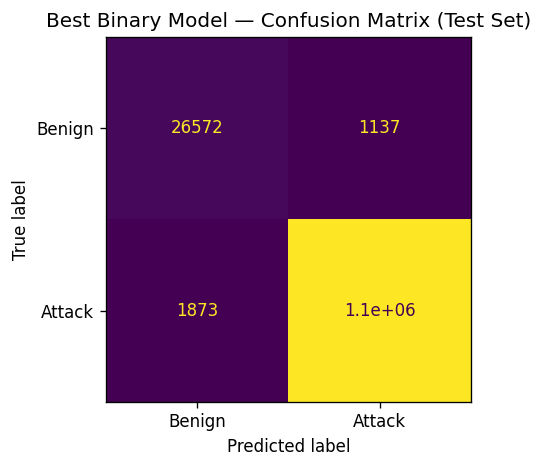

In [4]:
# Confusion matrix for best binary model
best_bin = load('models/best_binary_model.pkl')
y_pred_best = best_bin.predict(X_test)
cm = confusion_matrix(y_bin_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Benign','Attack']).plot(ax=ax, colorbar=False)
ax.set_title('Best Binary Model — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('models/confusion_matrix_binary.png', dpi=150)
plt.show()

## 3. Family Model Comparison (33 Attack Classes)

In [6]:
family_models = ['lr', 'rf', 'xgb', 'lgbm']
family_results = []

for name in family_models:
    path = f'models/family_{name}.pkl'
    if not os.path.exists(path):
        print(f'[SKIP] {path} not found')
        continue
    model = load(path)
    y_pred = model.predict(X_test)
    family_results.append({
        'Model':       name.upper(),
        'Accuracy':    accuracy_score(y_fam_test, y_pred),
        'Macro-F1':    f1_score(y_fam_test, y_pred, average='macro',    zero_division=0),
        'Weighted-F1': f1_score(y_fam_test, y_pred, average='weighted', zero_division=0),
    })

family_df = pd.DataFrame(family_results).sort_values('Macro-F1', ascending=False)
family_df.style.format('{:.4f}', subset=['Accuracy','Macro-F1','Weighted-F1']) \
               .background_gradient(cmap='Blues', subset=['Macro-F1'])

,Model,Accuracy,Macro-F1,Weighted-F1
1,RF,0.9938,0.7601,0.9933
2,XGB,0.9910,0.7215,0.9908
0,LR,0.8010,0.4914,0.7666
3,LGBM,0.1452,0.0125,0.0404


## 4. Bar Chart — Binary F1 Comparison

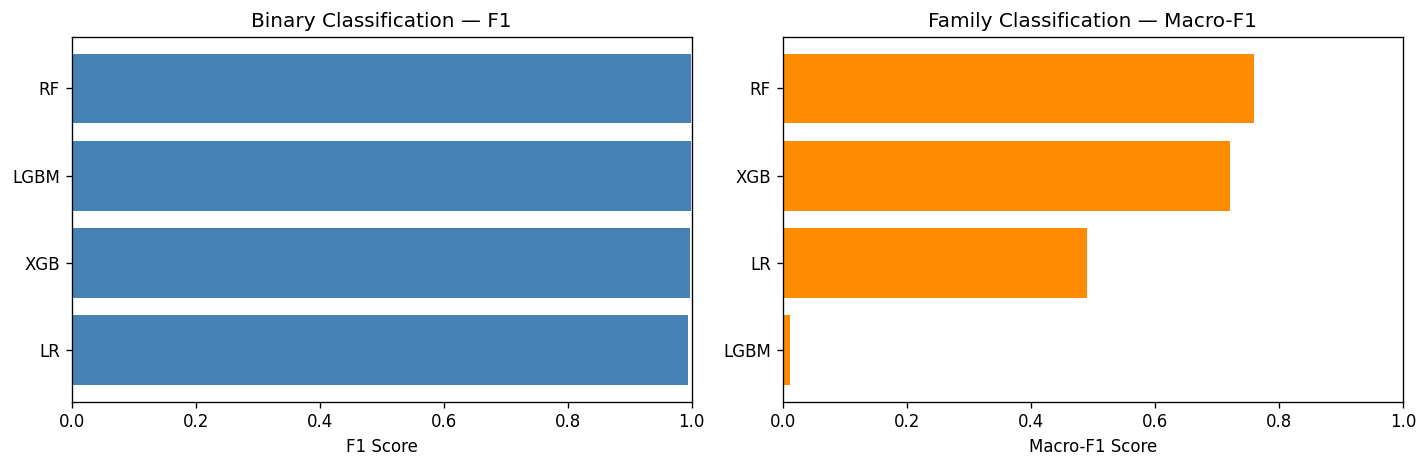

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Binary F1
if binary_results:
    bdf = pd.DataFrame(binary_results).sort_values('F1')
    axes[0].barh(bdf['Model'], bdf['F1'], color='steelblue')
    axes[0].set_xlabel('F1 Score')
    axes[0].set_title('Binary Classification — F1')
    axes[0].set_xlim(0, 1)

# Family Macro-F1
if family_results:
    fdf = pd.DataFrame(family_results).sort_values('Macro-F1')
    axes[1].barh(fdf['Model'], fdf['Macro-F1'], color='darkorange')
    axes[1].set_xlabel('Macro-F1 Score')
    axes[1].set_title('Family Classification — Macro-F1')
    axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig('models/model_comparison.png', dpi=150)
plt.show()

---
## 5. [INTEGRATION] Member 2 — Spectral Feature Augmentation
> **Instructions for Member 2:**  
> 1. Run your `spectral_features.py` to generate `X_train_spectral.pkl`, `X_val_spectral.pkl`, `X_test_spectral.pkl`  
> 2. Uncomment and run the cell below to evaluate the uplift.

In [8]:
# ── UNCOMMENT AFTER MEMBER 2 DELIVERS SPECTRAL FEATURES ──────────────────────
# import numpy as np
#
# X_test_spectral = load('X_test_spectral.pkl')
# X_test_aug = np.hstack([X_test, X_test_spectral])   # augment
#
# best_bin_spec = load('models/best_binary_model_spectral.pkl')  # retrained
# y_pred_spec   = best_bin_spec.predict(X_test_aug)
# f1_spec       = f1_score(y_bin_test, y_pred_spec)
# f1_base       = max(r['F1'] for r in binary_results)
#
# print(f'Baseline F1           : {f1_base:.4f}')
# print(f'Spectral-augmented F1 : {f1_spec:.4f}')
# print(f'Delta (uplift)        : {f1_spec - f1_base:+.4f}')
print('[STUB] Waiting for Member 2 spectral features.')

[STUB] Waiting for Member 2 spectral features.


---
## 6. [INTEGRATION] Member 3 — Federated Learning Global Evaluation
> **Instructions for Member 3:**  
> 1. Complete `fl_server.py` / `fl_client.py` training rounds  
> 2. Export the global federated model as `models/federated_global_model.pkl`  
> 3. Uncomment and run the cell below to compare against baseline.

In [9]:
# ── UNCOMMENT AFTER MEMBER 3 DELIVERS FEDERATED GLOBAL MODEL ─────────────────
# fl_model   = load('models/federated_global_model.pkl')
# y_pred_fl  = fl_model.predict(X_test)
# f1_fl      = f1_score(y_bin_test, y_pred_fl)
# f1_base    = max(r['F1'] for r in binary_results)
#
# print(f'Centralized best F1   : {f1_base:.4f}')
# print(f'Federated global F1   : {f1_fl:.4f}')
# print(f'Privacy-utility tradeoff: {f1_fl - f1_base:+.4f}')
print('[STUB] Waiting for Member 3 federated global model.')

[STUB] Waiting for Member 3 federated global model.


---
## 7. Save Summary CSV

In [10]:
# Save all results to CSV for the final report
if binary_results:
    pd.DataFrame(binary_results).to_csv('models/binary_results.csv', index=False)
    print('Saved: models/binary_results.csv')
if family_results:
    pd.DataFrame(family_results).to_csv('models/family_results.csv', index=False)
    print('Saved: models/family_results.csv')

Saved: models/binary_results.csv
Saved: models/family_results.csv
